## Projeto Prático – Ciência de Dados
Malu Pinto de Brito     
Dataset escolhido: Pima Indians Diabetes

### Etapa 1 — Análise Exploratória de Dados (EDA)

1.1 Compreensão do domínio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [2]:
dt = pd.read_csv('diabetes.csv')
dt.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


O dataset analisa a incidência de diabetes no grupo indígena norte-americano Pima, considerando exclusivamente mulheres dessa população. As características avaliadas no estudo incluem: número de gestações, concentração de glicose no sangue obtida em exame, pressão arterial diastólica (mmHg), Medida da dobra cutânea do tríceps (mm), nível de insulina no sangue, índice de massa corporal (IMC), função de hereditariedade do diabetes, idade e o resultado do diagnóstico. Entre essas variáveis, apenas a variável resultado é categórica.

1.2 Estatísticas descritivas

In [3]:
dt.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
dt.mode()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.0,99,70.0,0.0,0.0,32.0,0.254,22.0,0.0
1,NaN,100,NaN,NaN,NaN,NaN,0.258,NaN,NaN


In [5]:
dt.median()

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

O dataset possui 768 registros de mulheres do povo indígena Pima, com média de 3,8 gestações, 33 anos de idade e IMC médio de aproximadamente 32, indicando tendência a sobrepeso. A glicose média é cerca de 120, valor relativamente elevado e relevante para o estudo de diabetes. A variável Outcome apresenta média de 0,35, indicando que cerca de 35% das mulheres do conjunto de dados possuem diabetes, enquanto a maioria não possui a doença. Também é possível observar a presença de valores iguais a zero em variáveis como glicose, pressão arterial, medida da dobra cutânea do tríceps e insulina, o que pode indicar dados ausentes ou não registrados no dataset.

1.3 Visualização das distribuições

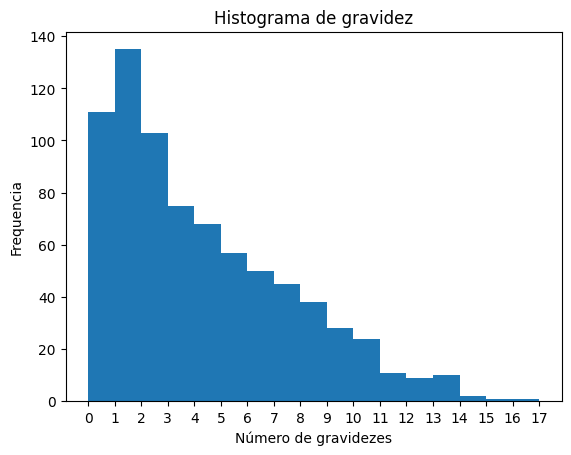

In [6]:
plt.hist(dt['Pregnancies'], bins=range(0, 18))
plt.xlabel('Número de gravidezes')
plt.ylabel('Frequencia')
plt.title('Histograma de gravidez')
plt.xticks(range(0, 18))
plt.show()

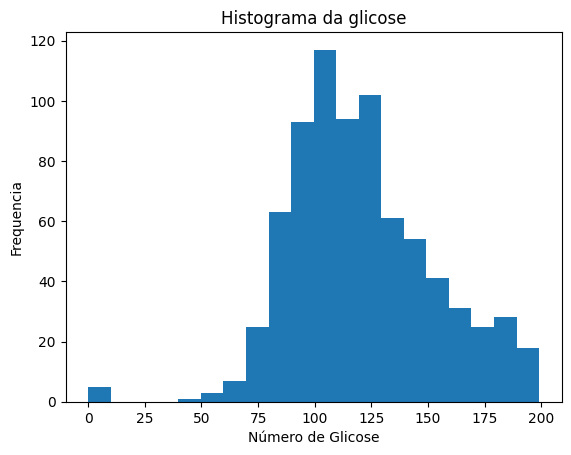

In [7]:
plt.hist(dt['Glucose'], bins=20)
plt.xlabel('Número de Glicose')
plt.ylabel('Frequencia')
plt.title('Histograma da glicose')
plt.show()

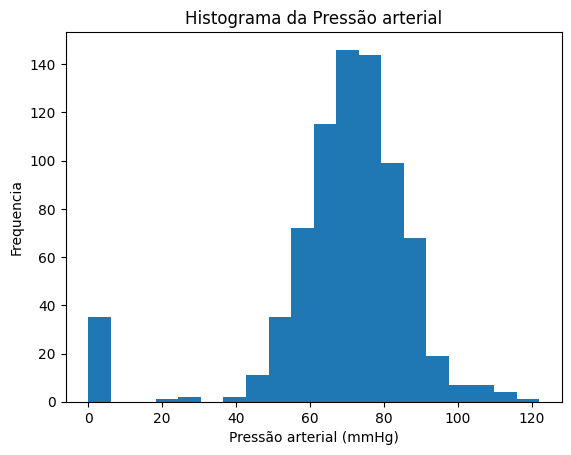

In [8]:
plt.hist(dt['BloodPressure'], bins=20)
plt.xlabel('Pressão arterial (mmHg)')
plt.ylabel('Frequencia')
plt.title('Histograma da Pressão arterial')
plt.show()

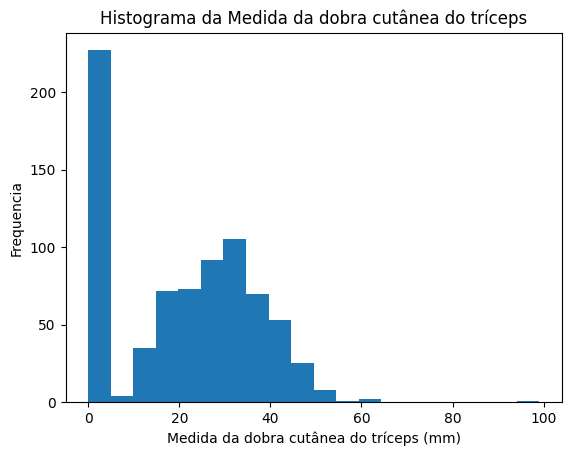

In [9]:
plt.hist(dt['SkinThickness'], bins=20)
plt.xlabel('Medida da dobra cutânea do tríceps (mm)')
plt.ylabel('Frequencia')
plt.title('Histograma da Medida da dobra cutânea do tríceps')
plt.show()

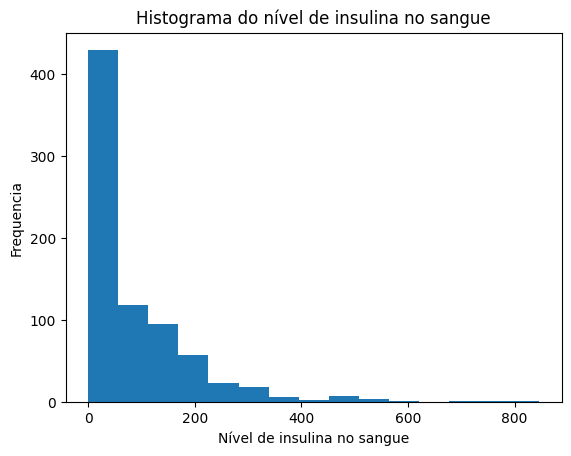

In [10]:
plt.hist(dt['Insulin'], bins=15)
plt.xlabel('Nível de insulina no sangue')
plt.ylabel('Frequencia')
plt.title('Histograma do nível de insulina no sangue')
plt.show()

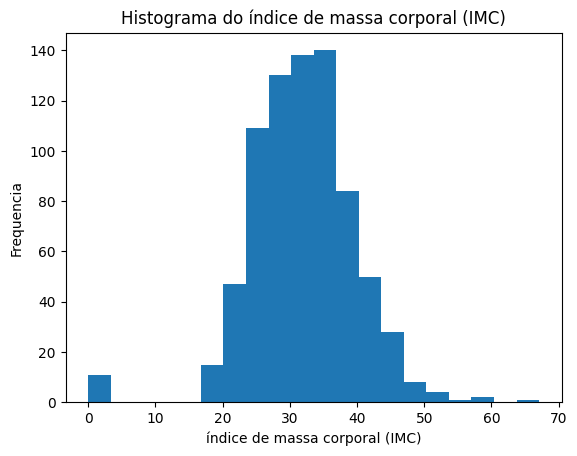

In [11]:
plt.hist(dt['BMI'], bins=20)
plt.xlabel('índice de massa corporal (IMC)')
plt.ylabel('Frequencia')
plt.title('Histograma do índice de massa corporal (IMC)')
plt.show()

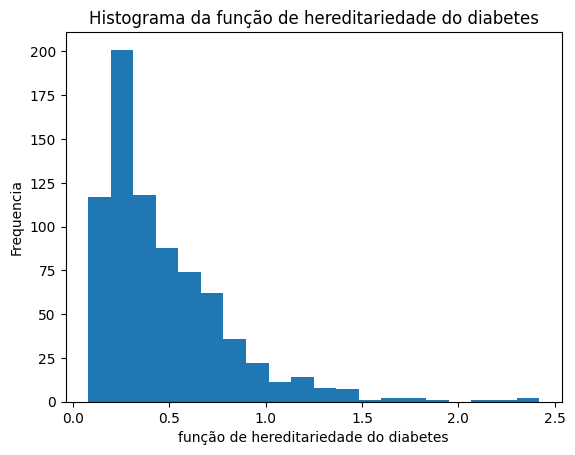

In [12]:
plt.hist(dt['DiabetesPedigreeFunction'], bins=20)
plt.xlabel('função de hereditariedade do diabetes')
plt.ylabel('Frequencia')
plt.title('Histograma da função de hereditariedade do diabetes')
plt.show()

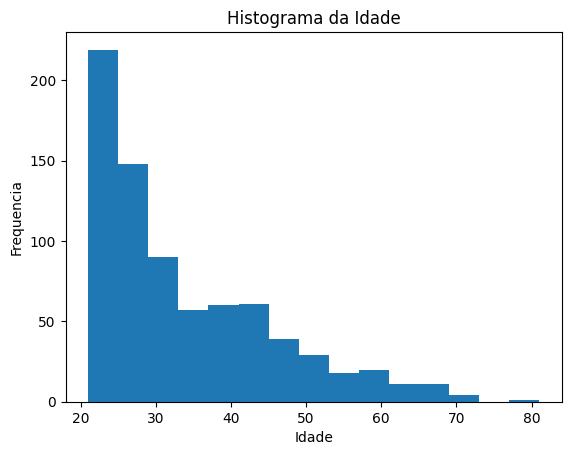

In [13]:
plt.hist(dt['Age'], bins=15)
plt.xlabel('Idade')
plt.ylabel('Frequencia')
plt.title('Histograma da Idade')
plt.show()

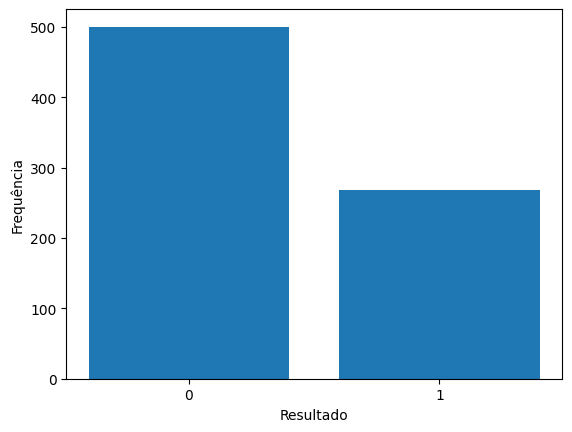

In [14]:
counts = dt['Outcome'].value_counts()
plt.bar(counts.index.astype(str), counts.values) 
plt.xlabel('Resultado')
plt.ylabel('Frequência')
plt.show()

Text(0.5, 1.0, 'Gravidez')

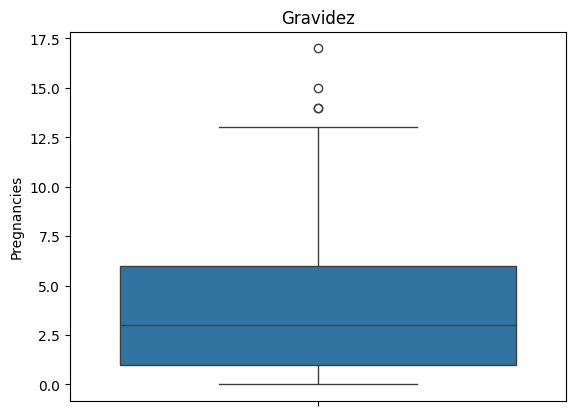

In [15]:
sns.boxplot(dt['Pregnancies']).set_title('Gravidez')

Text(0.5, 1.0, 'Clicose')

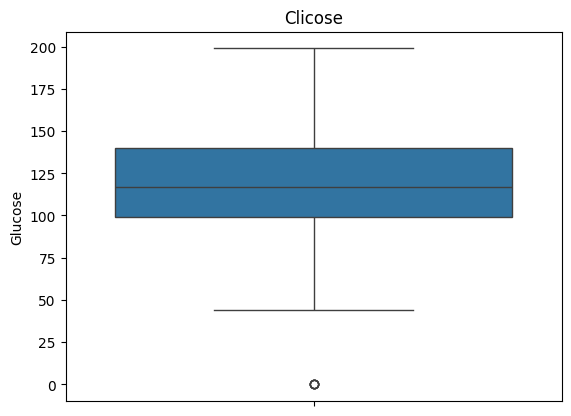

In [16]:
sns.boxplot(dt['Glucose']).set_title('Clicose')

Text(0.5, 1.0, 'Pressão Arterial')

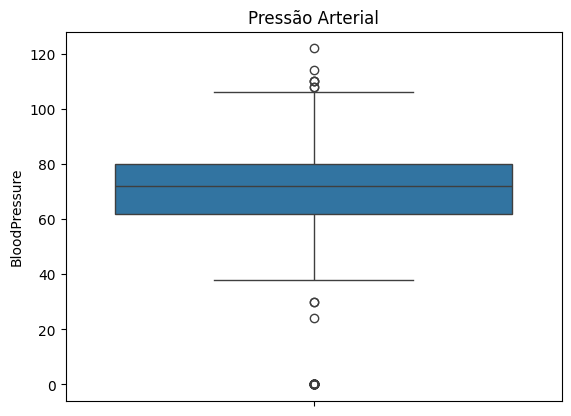

In [17]:
sns.boxplot(dt['BloodPressure']).set_title('Pressão Arterial')

Text(0.5, 1.0, 'Medida da dobra cutânea do tríceps')

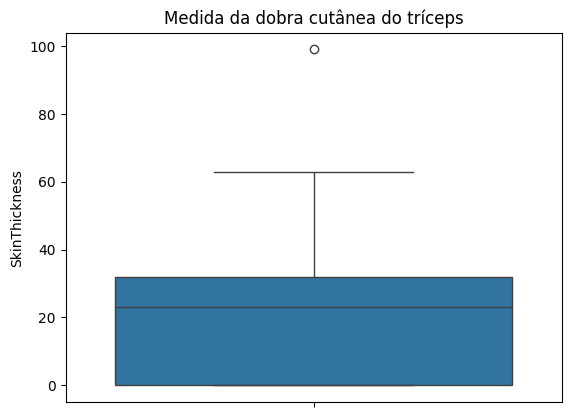

In [18]:
sns.boxplot(dt['SkinThickness']).set_title('Medida da dobra cutânea do tríceps')

Text(0.5, 1.0, 'Nível de insulina no sangue')

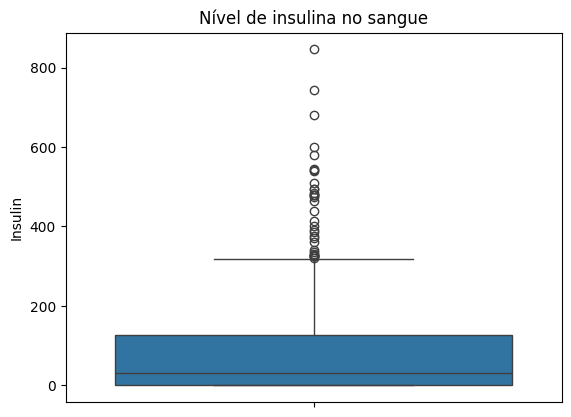

In [19]:
sns.boxplot(dt['Insulin']).set_title('Nível de insulina no sangue')

Text(0.5, 1.0, 'índice de massa corporal')

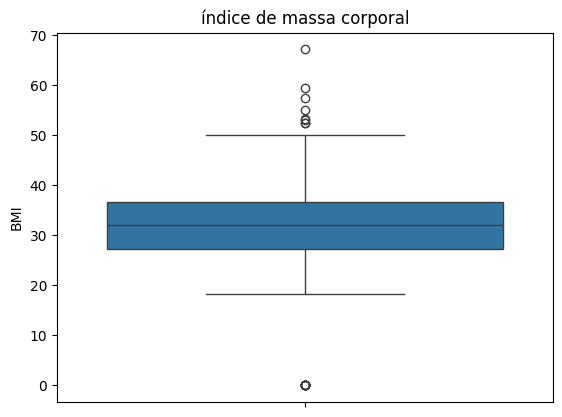

In [20]:
sns.boxplot(dt['BMI']).set_title('índice de massa corporal')

Text(0.5, 1.0, 'função de hereditariedade do diabetes')

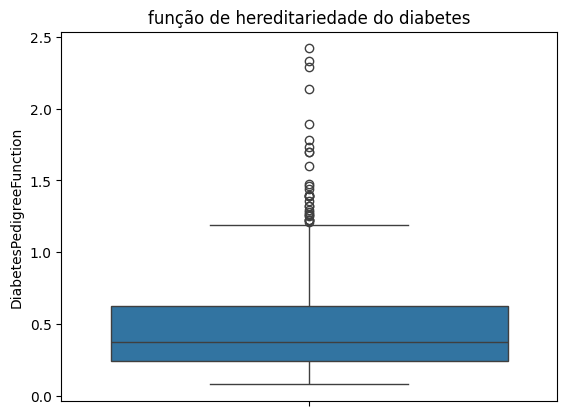

In [21]:
sns.boxplot(dt['DiabetesPedigreeFunction']).set_title('função de hereditariedade do diabetes')

<Axes: xlabel='Outcome', ylabel='BloodPressure'>

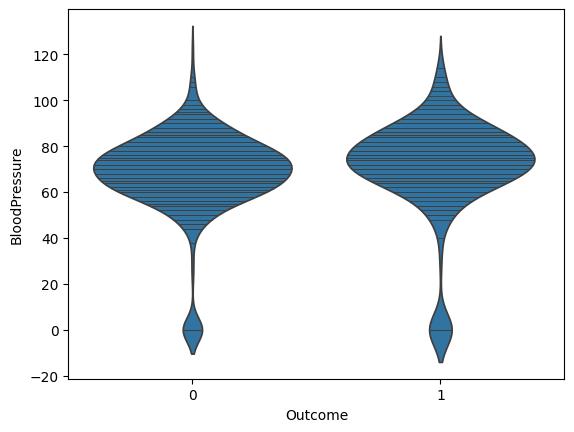

In [22]:
sns.violinplot(x='Outcome', y='BloodPressure', data=dt, inner='stick')

<Axes: xlabel='Outcome', ylabel='Glucose'>

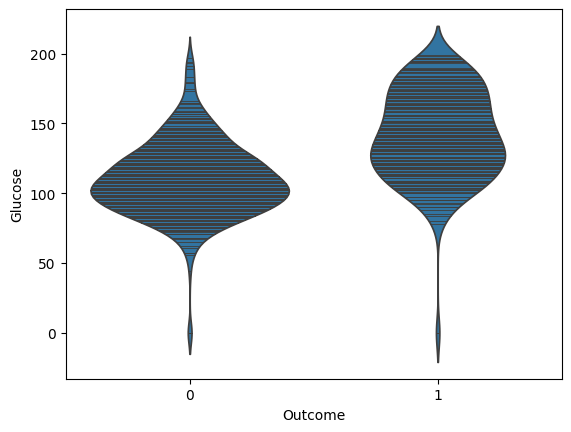

In [23]:
sns.violinplot(x='Outcome', y='Glucose', data=dt, inner='stick')

<Axes: xlabel='Outcome', ylabel='SkinThickness'>

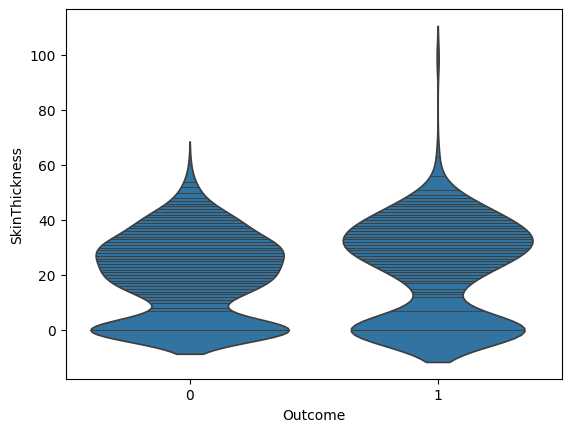

In [24]:
sns.violinplot(x='Outcome', y='SkinThickness', data=dt, inner='stick')

<Axes: xlabel='Outcome', ylabel='Insulin'>

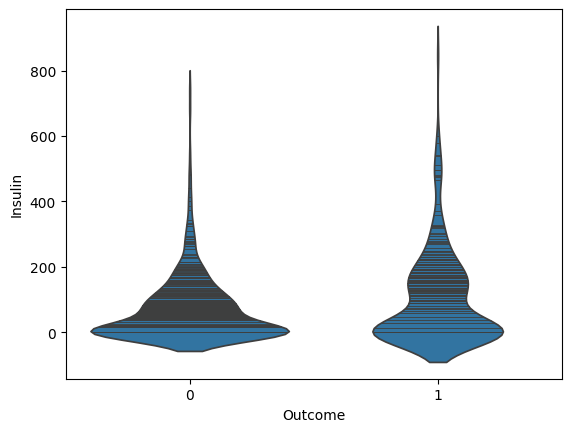

In [25]:
sns.violinplot(x='Outcome', y='Insulin', data=dt, inner='stick')

<Axes: xlabel='Outcome', ylabel='BMI'>

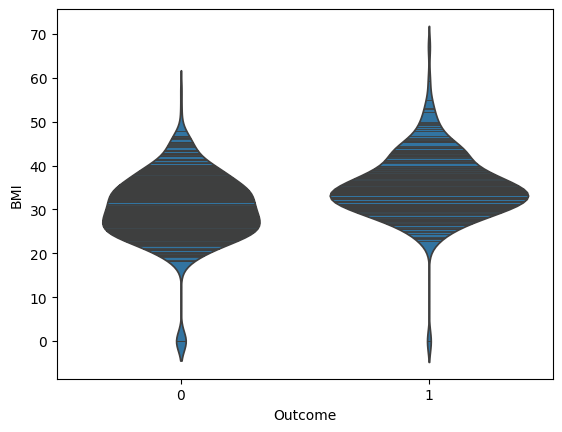

In [26]:
sns.violinplot(x='Outcome', y='BMI', data=dt, inner='stick')

<Axes: xlabel='Outcome', ylabel='DiabetesPedigreeFunction'>

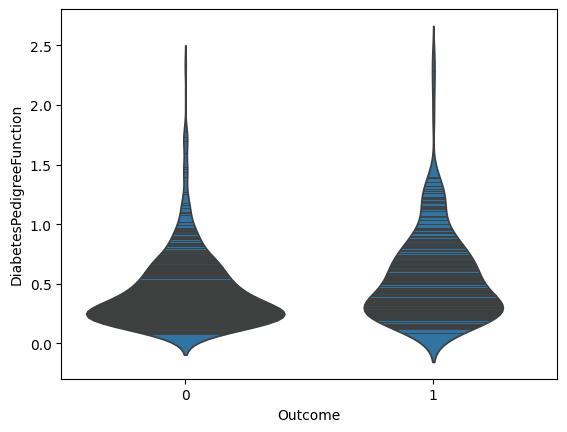

In [27]:
sns.violinplot(x='Outcome', y='DiabetesPedigreeFunction', data=dt, inner='stick')

A análise das variáveis revelou padrões distintos de distribuição e integridade dos dados. Variáveis como Gravidez, Nível de Insulina, Função de Hereditariedade e Idade apresentam uma clara assimetria positiva, caracterizada por uma concentração de registros em valores baixos e caudas longas que se estendem à direita. No caso de Gravidez e Idade, os outliers identificados são fisicamente plausíveis e representam a diversidade real da amostra. Já para Insulina e Hereditariedade, os valores extremos são muito acentuados, exigindo atenção para entender se refletem casos clínicos graves ou ruído estatístico.

Por outro lado, Glicose, Pressão Arterial, IMC e Medida da dobra cutânea do tríceps exibem um comportamento mais simétrico em seu núcleo, mas são severamente afetadas por inconsistências. O ponto mais crítico é a presença de valores iguais a zero nestas colunas, com destaque para a Pressão Arterial e a Espessura da Pele, o que é biologicamente impossível para pacientes vivos e indica falhas de coleta ou dados faltantes mascarados. Além disso, o IMC e a Espessura da Pele apresentam outliers muito elevados no extremo oposto, que podem indicar tanto casos extremos de obesidade quanto erros de medição manual.

1.4 Identificação de inconsistências, nulls e outliers

In [28]:
dt_limpo = dt.copy()
colunas_com_erro = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
dt_limpo[colunas_com_erro] = dt_limpo[colunas_com_erro].replace(0, np.nan)

In [29]:
def iqr(coluna):
    Q1 = coluna.quantile(0.25)
    Q3 = coluna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dt[
        (coluna < limite_inferior) |
        (coluna > limite_superior)
    ]
    return outliers

In [30]:
iqr(dt_limpo['Pregnancies'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
88,15,136,70,32,110,37.1,0.153,43,1
159,17,163,72,41,114,40.9,0.817,47,1
298,14,100,78,25,184,36.6,0.412,46,1
455,14,175,62,30,0,33.6,0.212,38,1


In [31]:
iqr(dt_limpo['Glucose'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [32]:
iqr(dt_limpo['BloodPressure'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
18,1,103,30,38,83,43.3,0.183,33,0
43,9,171,110,24,240,45.4,0.721,54,1
84,5,137,108,0,0,48.8,0.227,37,1
106,1,96,122,0,0,22.4,0.207,27,0
125,1,88,30,42,99,55.0,0.496,26,1
177,0,129,110,46,130,67.1,0.319,26,1
362,5,103,108,37,0,39.2,0.305,65,0
549,4,189,110,31,0,28.5,0.680,37,0
597,1,89,24,19,25,27.8,0.559,21,0
599,1,109,38,18,120,23.1,0.407,26,0


In [33]:
iqr(dt_limpo['SkinThickness'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
57,0,100,88,60,110,46.8,0.962,31,0
445,0,180,78,63,14,59.4,2.420,25,1
579,2,197,70,99,0,34.7,0.575,62,1


In [34]:
iqr(dt_limpo['Insulin'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
111,8,155,62,26,495,34.0,0.543,46,1
153,1,153,82,42,485,40.6,0.687,23,0
186,8,181,68,36,495,30.1,0.615,60,1
220,0,177,60,29,478,34.6,1.072,21,1
228,4,197,70,39,744,36.7,2.329,31,0
231,6,134,80,37,370,46.2,0.238,46,1
247,0,165,90,33,680,52.3,0.427,23,0
248,9,124,70,33,402,35.4,0.282,34,0


In [35]:
iqr(dt_limpo['BMI'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
120,0,162,76,56,100,53.2,0.759,25,1
125,1,88,30,42,99,55.0,0.496,26,1
177,0,129,110,46,130,67.1,0.319,26,1
193,11,135,0,0,0,52.3,0.578,40,1
247,0,165,90,33,680,52.3,0.427,23,0
303,5,115,98,0,0,52.9,0.209,28,1
445,0,180,78,63,14,59.4,2.420,25,1
673,3,123,100,35,240,57.3,0.880,22,0


In [36]:
iqr(dt_limpo['DiabetesPedigreeFunction'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
12,10,139,80,0,0,27.1,1.441,57,0
39,4,111,72,47,207,37.1,1.390,56,1
45,0,180,66,39,0,42.0,1.893,25,1
58,0,146,82,0,0,40.5,1.781,44,0
100,1,163,72,0,0,39.0,1.222,33,1
147,2,106,64,35,119,30.5,1.400,34,0
187,1,128,98,41,58,32.0,1.321,33,1
218,5,85,74,22,0,29.0,1.224,32,1
228,4,197,70,39,744,36.7,2.329,31,0


In [37]:
iqr(dt_limpo['Age'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
123,5,132,80,0,0,26.8,0.186,69,0
363,4,146,78,0,0,38.5,0.520,67,1
453,2,119,0,0,0,19.6,0.832,72,0
459,9,134,74,33,60,25.9,0.460,81,0
489,8,194,80,0,0,26.1,0.551,67,0
537,0,57,60,0,0,21.7,0.735,67,0
666,4,145,82,18,0,32.5,0.235,70,1
674,8,91,82,0,0,35.6,0.587,68,0
684,5,136,82,0,0,0.0,0.640,69,0


In [38]:
pacientes_sem_glicose = dt_limpo[dt_limpo['Glucose'].isnull()]
display(pacientes_sem_glicose)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,NaN,48.0,20.0,NaN,24.7,0.140,22,0
182,1,NaN,74.0,20.0,23.0,27.7,0.299,21,0
342,1,NaN,68.0,35.0,NaN,32.0,0.389,22,0
349,5,NaN,80.0,32.0,NaN,41.0,0.346,37,1
502,6,NaN,68.0,41.0,NaN,39.0,0.727,41,1


In [39]:
pacientes_sem_pressao = dt_limpo[dt_limpo['BloodPressure'].isnull()]
display(pacientes_sem_pressao)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
15,7,100.0,NaN,NaN,NaN,30.0,0.484,32,1
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,0
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21,0
78,0,131.0,NaN,NaN,NaN,43.2,0.270,26,1
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22,0
172,2,87.0,NaN,23.0,NaN,28.9,0.773,25,0
193,11,135.0,NaN,NaN,NaN,52.3,0.578,40,1
222,7,119.0,NaN,NaN,NaN,25.2,0.209,37,0
261,3,141.0,NaN,NaN,NaN,30.0,0.761,27,1


In [40]:
pacientes_sem_skin = dt_limpo[dt_limpo['SkinThickness'].isnull()]
display(pacientes_sem_skin)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1
10,4,110.0,92.0,NaN,NaN,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123.0,72.0,NaN,NaN,36.3,0.258,52,1
758,1,106.0,76.0,NaN,NaN,37.5,0.197,26,0
759,6,190.0,92.0,NaN,NaN,35.5,0.278,66,1
762,9,89.0,62.0,NaN,NaN,22.5,0.142,33,0


In [41]:
pacientes_sem_insulina= dt_limpo[dt_limpo['Insulin'].isnull()]
display(pacientes_sem_insulina)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170.0,74.0,31.0,NaN,44.0,0.403,43,1
762,9,89.0,62.0,NaN,NaN,22.5,0.142,33,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [42]:
pacientes_sem_IMC = dt_limpo[dt_limpo['BMI'].isnull()]
display(pacientes_sem_IMC)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,0
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21,0
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22,0
145,0,102.0,75.0,23.0,NaN,NaN,0.572,21,0
371,0,118.0,64.0,23.0,89.0,NaN,1.731,21,0
426,0,94.0,NaN,NaN,NaN,NaN,0.256,25,0
494,3,80.0,NaN,NaN,NaN,NaN,0.174,22,0
522,6,114.0,NaN,NaN,NaN,NaN,0.189,26,0
684,5,136.0,82.0,NaN,NaN,NaN,0.640,69,0


Para o tratamento da base de dados, iniciei a substituição de zeros por NaNs nas colunas de Glicose, Pressão, IMC, Insulina e Espessura da Pele, pois valores nulos nessas variáveis são biologicamente impossíveis e sua presença mascarava a identificação de outliers reais pelo método IQR. Na análise individual, variáveis como Gravidez, Idade e Função de Hereditariedade apresentaram outliers elevados que, embora estatisticamente extremos, refletem traços culturais e a forte carga genética do grupo, sendo cruciais para a precisão do modelo. Já na Insulina e no IMC, os valores ultra-altos são consistentes com quadros de resistência severa e obesidade mórbida, devendo ser mantidos para não privar o algoritmo de informações sobre estados metabólicos críticos.

Em contrapartida, a Pressão Arterial exibiu outliers inferiores suspeitos e um alto volume de dados faltantes que podem subestimar a gravidade cardiovascular da amostra. O cenário mais grave ocorre na Espessura da Pele, onde o valor 99 indica um provável erro técnico e a vasta quantidade de nuloss, que frequentemente coincide com a falta de dados de Insulina,o que sugere falhas estruturais na coleta em determinados locais. Esses "buracos" e inconsistências impactam severamente a análise, pois podem gerar correlações ilusórias ou ocultar padrões fundamentais de risco, exigindo uma estratégia de imputação cuidadosa para que as perdas de informação não enviesem a classificação final do diabetes.

1.5 Análise de correlação


In [43]:
corr = dt_limpo.corr()

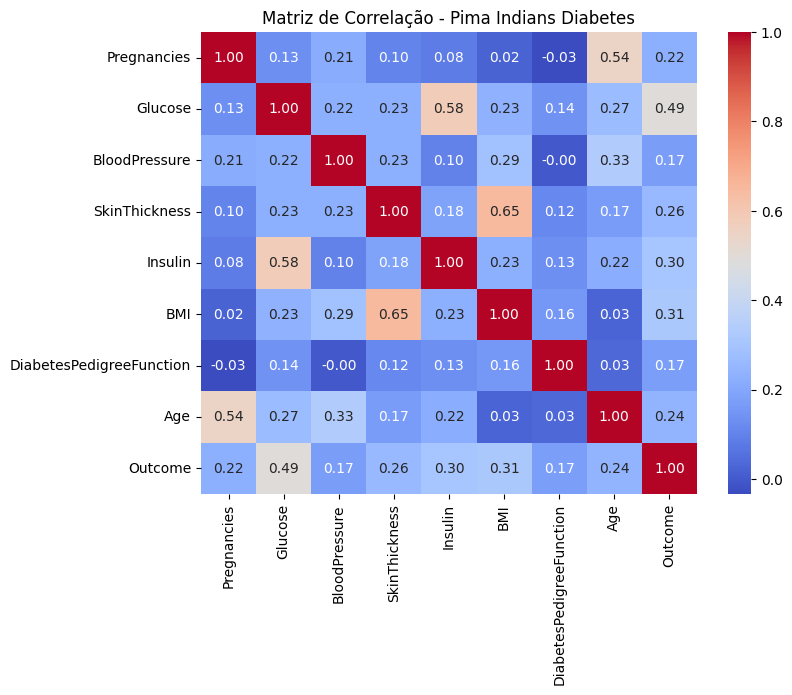

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Pima Indians Diabetes')
plt.show()

Analisando os coeficientes do heatmap, as correlações mais fortes com a variável alvo (Outcome) são a Glucose ($0.49$) e o BMI ($0.31$), seguidas de perto pela Insulin ($0.30$). Esses números confirmam que o nível de açúcar no sangue, o índice de massa corporal e a quantidade de insulina são os preditores mais influentes para o diagnóstico de diabetes nesta amostra. Observa-se também uma correlação relevante entre Pregnancies e Age ($0.54$), o que é biologicamente esperado, já que o número de gestações tende a aumentar conforme a idade avança.
Por outro lado, as correlações mais fracas ou quase inexistentes com o desfecho final aparecem na BloodPressure ($0.17$) e na DiabetesPedigreeFunction ($0.17$), indicando que, isoladamente, a pressão arterial e a função de hereditariedade não são os determinantes principais para prever a doença neste conjunto de dados específico. No quesito redundância, destaca-se a relação entre SkinThickness e BMI ($0.65$) e entre Glucose e Insulin ($0.58$). Embora não sejam correlações perfeitas, elas sugerem que essas variáveis compartilham informações sobre a composição corporal e o metabolismo da glicose, o que permite considerar a simplificação do modelo caso haja necessidade de reduzir a dimensionalidade.

1.6 Insights iniciais

A análise exploratória revelou que o dataset Pima possui uma estrutura de dados complexa, marcada por uma forte assimetria positiva em variáveis como Insulina, Idade e Função de Hereditariedade, onde as caudas longas e os outliers elevados não representam erros de medição, mas sim indicadores críticos de um perfil metabólico de alto risco. A identificação de inconsistências foi uma etapa vital do processo, uma vez que a presença de zeros indevidos em métricas como Glicose, IMC e Pressão Arterial funcionava como um ruído que mascarava a real distribuição dos dados. Após a conversão desses valores para NaNs e a análise via IQR, observou-se que a Glicose ($0.49$), o BMI ($0.31$) e a Insulina ($0.30$) consolidaram-se como os preditores mais robustos do Outcome, reforçando a hipótese de que o diabetes nesta população está intrinsecamente ligado à resistência insulínica e à obesidade persistente.Estruturalmente, a redundância identificada entre Espessura da Pele e IMC ($0.65$), somada à forte relação entre Glicose e Insulina ($0.58$), confirma a consistência fisiológica da base e sugere caminhos para a simplificação de modelos futuros. Embora variáveis como Pressão Arterial e Pedigree apresentem correlações mais sutis ($0.17$), elas compõem o quadro clínico sistêmico que, junto ao desgaste biológico evidenciado pela Idade, define a probabilidade do diagnóstico. Em suma, a EDA demonstrou que, apesar das falhas de registro identificadas em exames específicos, o dataset preserva padrões biológicos valiosos, exigindo apenas uma estratégia de imputação cuidadosa para que as perdas de informação não enviesem a classificação final do diabetes.

### Etapa 2 — Pré-processamento de Dados

2.2 Tratamento de valores ausentes e inconsistências

In [45]:
dt_limpo.dropna(subset=['Glucose'], inplace=True)

In [46]:
dt_limpo['Age_Group'] = pd.cut(dt_limpo['Age'], bins=[20, 30, 40, 50, 90], labels=['20-30', '30-40', '40-50', '50+'])
dt_limpo['BloodPressure'] = dt_limpo['BloodPressure'].fillna(dt_limpo.groupby('Age_Group')['BloodPressure'].transform('median'))
dt_limpo.drop(columns=['Age_Group'], inplace=True)

In [47]:
dt_limpo.drop(columns=['SkinThickness'], inplace=True)

In [48]:
dt_limpo['Glucose_Group'] = pd.cut(dt_limpo['Glucose'], bins=[0, 100, 140, 300], labels=['Baixa', 'Normal', 'Alta'])
dt_limpo['Insulin'] = dt_limpo['Insulin'].fillna(dt_limpo.groupby('Glucose_Group')['Insulin'].transform('median'))
dt_limpo.drop(columns=['Glucose_Group'], inplace=True)

In [49]:
dt_limpo['Age_Group'] = pd.cut(dt_limpo['Age'], bins=[20, 30, 40, 50, 90], labels=['20-30', '30-40', '40-50', '50+'])
dt_limpo['BMI'] = dt_limpo['BMI'].fillna(dt_limpo.groupby('Age_Group')['BMI'].transform('median'))
dt_limpo.drop(columns=['Age_Group'], inplace=True)

As estratégias de tratamento de dados foram selecionadas com base na relevância biológica e na integridade estatística de cada variável, priorizando a manutenção da qualidade informacional sobre a quantidade bruta de registros. Para a Glicose, optou-se pela exclusão das cinco linhas ausentes por ser o principal preditor do diagnóstico, evitando assim o ruído de uma imputação artificial em um dado tão crítico.  Já para Pressão Arterial, Insulina e IMC, aplicou-se a imputação condicional por grupos (Idade e Glicose), utilizando a mediana em vez da média para garantir robustez contra os outliers severos identificados na EDA, respeitando as variações fisiológicas naturais de cada perfil de paciente.  Por fim, a coluna SkinThickness foi integralmente removida devido à sua elevada taxa de dados faltantes (aproximadamente 49%) e à sua redundância estatística com o IMC, eliminando variáveis ruidosas que poderiam prejudicar a convergência e a precisão do futuro modelo de classificação.

2.3 Tratamento de outliers

In [50]:
dt_limpo['Age_Group'] = pd.cut(dt_limpo['Age'], bins=[20, 30, 40, 50, 90], labels=['20-30', '30-40', '40-50', '50+'])
dt_limpo.loc[dt_limpo['BloodPressure'] < 40, 'BloodPressure'] = np.nan
dt_limpo['BloodPressure'] = dt_limpo['BloodPressure'].fillna(dt_limpo.groupby('Age_Group')['BloodPressure'].transform('median'))
dt_limpo.drop(columns=['Age_Group'], inplace=True)

A estratégia de tratamento de dados priorizou a preservação de outliers biológicos em variáveis como Gravidez, Idade, Pedigree, Insulina e IMC, pois esses valores extremos refletem casos reais de alta carga genética ou resistência metabólica severa, sendo fundamentais para a precisão preditiva do modelo.  Em contrapartida, na Pressão Arterial, optou-se por intervir apenas nos valores inferiores a 40 mmHg, por serem clinicamente implausíveis e indicarem falhas técnicas de medição.  Esses ruídos foram substituídos pela mediana da respectiva faixa etária da paciente, garantindo que o dataset fosse limpo de erros grosseiros sem perder os registros de hipertensão (outliers superiores), que são valiosos para identificar o risco de diabetes.

2.4 Transformações de dados

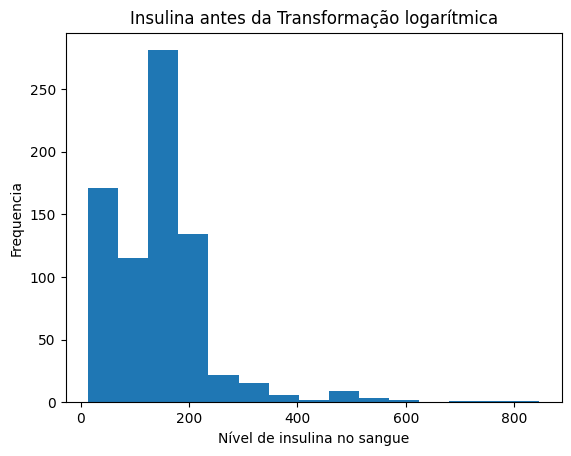

In [51]:
plt.hist(dt_limpo['Insulin'], bins=15)
plt.xlabel('Nível de insulina no sangue')
plt.ylabel('Frequencia')
plt.title('Insulina antes da Transformação logarítmica')
plt.show()

In [52]:
dt_limpo['Insulin'] = np.log1p(dt_limpo['Insulin'])

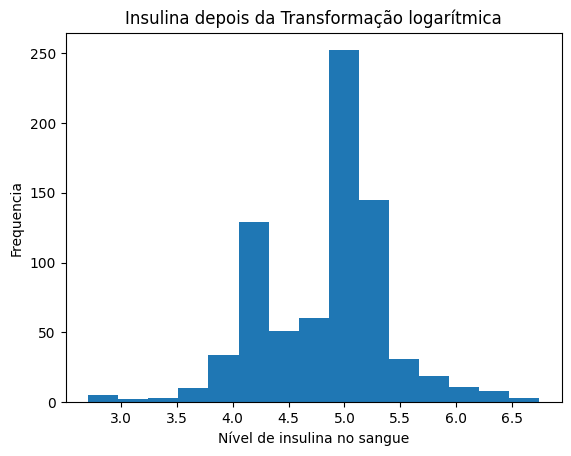

In [53]:
plt.hist(dt_limpo['Insulin'], bins=15)
plt.xlabel('Nível de insulina no sangue')
plt.ylabel('Frequencia')
plt.title('Insulina depois da Transformação logarítmica')
plt.show()

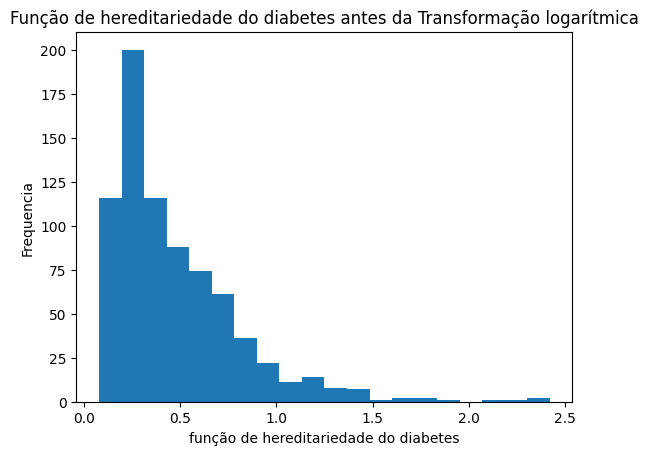

In [54]:
plt.hist(dt_limpo['DiabetesPedigreeFunction'], bins=20)
plt.xlabel('função de hereditariedade do diabetes')
plt.ylabel('Frequencia')
plt.title('Função de hereditariedade do diabetes antes da Transformação logarítmica')
plt.show()

In [55]:
dt_limpo['DiabetesPedigreeFunction'] = np.log1p(dt_limpo['DiabetesPedigreeFunction'])

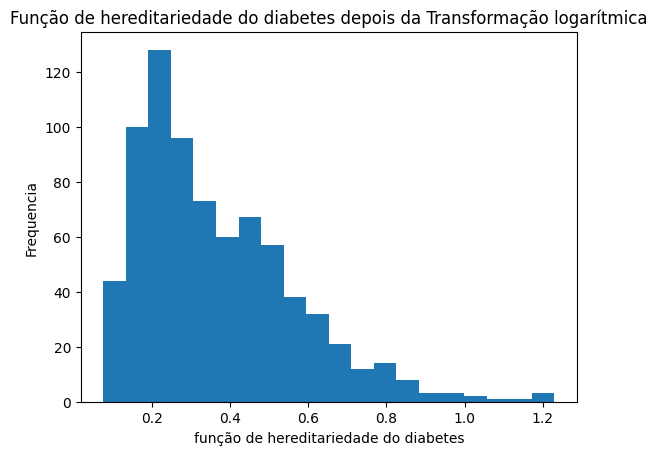

In [56]:
plt.hist(dt_limpo['DiabetesPedigreeFunction'], bins=20)
plt.xlabel('função de hereditariedade do diabetes')
plt.ylabel('Frequencia')
plt.title('Função de hereditariedade do diabetes depois da Transformação logarítmica')
plt.show()

In [57]:
dt_limpo.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,5.273000,33.6,0.486738,50,1
1,1,85.0,66.0,4.241327,26.6,0.300845,31,0
2,8,183.0,64.0,5.273000,23.3,0.514021,32,1
3,1,89.0,66.0,4.553877,28.1,0.154436,21,0
4,0,137.0,40.0,5.129899,43.1,1.190279,33,1


In [58]:
X = dt_limpo.drop(columns=['Outcome'])
y = dt_limpo['Outcome']

In [59]:
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)
X_std.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.636943,0.862287,-0.048363,0.805063,0.168794,0.609393,1.421971
1,-0.845630,-1.202229,-0.559697,-1.051137,-0.849305,-0.326223,-0.193065
2,1.229971,2.009241,-0.730142,0.805063,-1.329266,0.746710,-0.108063
3,-0.845630,-1.071148,-0.559697,-0.488793,-0.631141,-1.063113,-1.043083
4,-1.142144,0.501816,-2.775478,0.547594,1.550499,4.150388,-0.023061


In [60]:
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=X.columns)
X_minmax.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.670968,0.390244,0.635888,0.314928,0.356534,0.483333
1,0.058824,0.264516,0.317073,0.380121,0.171779,0.195523,0.166667
2,0.470588,0.896774,0.292683,0.635888,0.104294,0.380165,0.183333
3,0.058824,0.290323,0.317073,0.457607,0.202454,0.068711,0.000000
4,0.000000,0.600000,0.000000,0.600411,0.509202,0.965907,0.200000


A análise visual dos histogramas revelou que as variáveis Insulina e DiabetesPedigreeFunction apresentavam uma forte assimetria positiva, com longas caudas à direita que poderiam enviesar o modelo. Para corrigir isso, aplicou-se a Transformação Logarítmica, que foi bem-sucedida em aproximar essas distribuições de uma curva normal, reduzindo a magnitude dos valores extremos sem perder a informação biológica.
Na etapa de comparação entre os métodos de escala, observou-se que o MinMaxScaler comprimiu todos os registros no intervalo fixo de $0$ a $1$. Embora útil, essa técnica pode mascarar a importância de casos graves em datasets médicos. Por outro lado, o StandardScaler (escolhido como método final) transformou os dados para média $0$ e desvio padrão $1$, preservando a relação de distância dos outliers.  Esta escolha é a mais adequada para o dataset Pima, pois garante que variáveis com escalas distintas (como Glicose e Pedigree) tenham o mesmo peso inicial, enquanto mantém o destaque estatístico de pacientes com quadros metabólicos extremos, otimizando a performance de algoritmos sensíveis à escala como a Regressão Logística.

In [61]:
colunas_features = dt_limpo.columns.drop('Outcome')
dt_limpo[colunas_features] = scaler_std.fit_transform(dt_limpo[colunas_features])

2.5 Codificação de variáveis categóricas

A etapa de codificação de variáveis categóricas foi dispensada neste projeto, uma vez que o dataset Pima Indians é composto exclusivamente por variáveis quantitativas contínuas e discretas. A variável alvo (Outcome) já se encontra em formato binário (0 e 1), estando pronta para o processamento pelos algoritmos de classificação sem a necessidade de transformações adicionais de natureza categórica.

2.6 Redução de dimensionalidade (Modelo não supervisionado)

In [62]:
dt_limpo.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.636943,0.862287,-0.048363,0.805063,0.168794,0.609393,1.421971,1
1,-0.845630,-1.202229,-0.559697,-1.051137,-0.849305,-0.326223,-0.193065,0
2,1.229971,2.009241,-0.730142,0.805063,-1.329266,0.746710,-0.108063,1
3,-0.845630,-1.071148,-0.559697,-0.488793,-0.631141,-1.063113,-1.043083,0
4,-1.142144,0.501816,-2.775478,0.547594,1.550499,4.150388,-0.023061,1


In [63]:
pca = PCA(n_components=2)
colunas_features = dt_limpo.columns.drop('Outcome')
X_pca = pca.fit_transform(dt_limpo[colunas_features])
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
variancia = pca.explained_variance_ratio_

In [64]:
df_pca.head()

,PC1,PC2
0,1.733952,0.247882
1,-1.948884,0.456783
2,1.162273,-0.120760
3,-2.014596,-0.020202
4,0.053965,-3.268067


In [65]:
print(f"Variância explicada: PC1 ({variancia[0]*100:.2f}%) | PC2 ({variancia[1]*100:.2f}%)")
print(f"Total de informação preservada: {sum(variancia)*100:.2f}%")

Variância explicada: PC1 (32.46%) | PC2 (19.86%)
Total de informação preservada: 52.32%


O PCA (Principal Component Analysis) é uma técnica de aprendizado não supervisionado que transforma um conjunto de variáveis correlacionadas em um novo conjunto de componentes linearmente independentes, denominados Componentes Principais. O objetivo é simplificar a estrutura dos dados, projetando-as em direções (eixos) que capturem a maior variabilidade possível do dataset original. Neste projeto, o PCA foi aplicado após a padronização dos dados, reduzindo as 7 dimensões originais para apenas 2 componentes (PC1 e PC2). A análise da variância explicada revelou que o PC1 retém 32.46% da informação, enquanto o PC2 retém 19.86%, totalizando 52.32% de informação preservada.
Uma das vantagens da aplicação foi a uma simplificação drástica do modelo, eliminando redundâncias e permitindo a visualização do agrupamento das pacientes em um gráfico bidimensional, o que facilita a identificação visual de padrões entre diabéticos e não diabéticos. Já o custo dessa simplificação foi a perda de aproximadamente 47.68% da variância original, o que pode impactar a precisão se o modelo depender de nuances sutis descartadas. Além disso, houve perda total de interpretabilidade direta, uma vez que os componentes são combinações matemáticas e não mais variáveis biológicas isoladas como "Glicose" ou "IMC".

In [67]:
dt_limpo.to_csv('pima_indians_diabetes_limpo.csv', index=False)

### Etapa 3 — Modelos Supervisionados

3.1 Definição do problema

O projeto utiliza o dataset Pima Indians Diabetes para realizar uma tarefa de Classificação Binária. Variável Alvo (Target): É a coluna Outcome, que representa a resposta que queremos prever, ou seja o resultado do diagnóstico. As variáveis explicativas (features) são o número de gestações, a concentração de glicose no sangue obtida em exame, a pressão arterial diastólica (mmHg), a medida da dobra cutânea do tríceps (mm), o nível de insulina no sangue, o índice de massa corporal (IMC), a função de hereditariedade do diabetes e a idade.

3.2 Algoritmos escolhidos

Regressão Logística: é um modelo básico para classificação binária, que calcula a probabilidade de uma pessoa ter diabetes usando uma função sigmoide. Como os dados foram padronizados com o StandardScaler, ele tende a funcionar bem. Também é fácil de interpretar, o que ajuda na análise dos resultados.

K-Nearest Neighbors (KNN): o KNN classifica uma nova pessoa olhando para as K mais parecidas com ela no conjunto de dados. Como no dataset Pima pessoas com valores parecidos (como IMC e glicose) costumam ter o mesmo diagnóstico, esse modelo consegue capturar bem essas semelhanças.

Árvore de Decisão (Decision Tree): esse modelo cria regras simples do tipo “se-então” para fazer a classificação (ex: “Se Glicose > 125 e Idade > 30, então tem diabetes”). Ele é fácil de entender e mostra claramente como a decisão foi tomada, além de conseguir lidar com relações mais complexas entre os dados.

3.3 Treinamento inicial

In [68]:
X = dt_limpo.drop(columns=['Outcome'])
y = dt_limpo['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [72]:
print(f"Acurácia Regressão Logística: {accuracy_score(y_test, log_reg.predict(X_test))*100:.2f}%")
print(f"Acurácia KNN: {accuracy_score(y_test, knn.predict(X_test))*100:.2f}%")
print(f"Acurácia Árvore de Decisão: {accuracy_score(y_test, tree.predict(X_test))*100:.2f}%")

Acurácia Regressão Logística: 77.78%
Acurácia KNN: 78.43%
Acurácia Árvore de Decisão: 68.63%


Após o treinamento com hiperparâmetros padrão, os modelos apresentaram desempenhos distintos na classificação do dataset Pima Indians. A Regressão Logística (77,78%) e o KNN (78,43%) demonstraram resultados sólidos e muito próximos, sugerindo que a padronização prévia dos dados foi eficaz para esses algoritmos sensíveis à escala.  O KNN obteve a maior acurácia inicial, indicando que a proximidade entre os perfis clínicos das pacientes é um forte indicativo do diagnóstico de diabetes.
Em contrapartida, a Árvore de Decisão (68,63%) apresentou o desempenho mais baixo. Essa discrepância ocorre, provavelmente, porque as árvores com configurações padrão tendem a sofrer de overfitting (decorar o treino) ou criar divisões muito rígidas que não generalizam bem para dados não vistos.  Essa diferença de quase 10% em relação aos outros modelos reforça a necessidade de realizar um ajuste fino (otimização) nos parâmetros da árvore para torná-la competitiva.

3.4 Overfitting e underfitting

In [73]:
acc_log_treino = accuracy_score(y_train, log_reg.predict(X_train))
acc_log_teste = accuracy_score(y_test, log_reg.predict(X_test))
print(f"Regressão Logística - Treino: {acc_log_treino:.2%}, Teste: {acc_log_teste:.2%}")

Regressão Logística - Treino: 77.38%, Teste: 77.78%


In [74]:
acc_knn_treino = accuracy_score(y_train, knn.predict(X_train))
acc_knn_teste = accuracy_score(y_test, knn.predict(X_test))
print(f"KNN - Treino: {acc_knn_treino:.2%}, Teste: {acc_knn_teste:.2%}")

KNN - Treino: 80.98%, Teste: 78.43%


In [75]:
acc_tree_treino = accuracy_score(y_train, tree.predict(X_train))
acc_tree_teste = accuracy_score(y_test, tree.predict(X_test))
print(f"Árvore de Decisão - Treino: {acc_tree_treino:.2%}, Teste: {acc_tree_teste:.2%}")

Árvore de Decisão - Treino: 100.00%, Teste: 68.63%


A comparação entre o desempenho nos conjuntos de treino e teste revelou comportamentos distintos de generalização entre os modelos:

Regressão Logística (77,38% Treino / 77,78% Teste): Apresentou o equilíbrio ideal. O fato da acurácia de teste ser ligeiramente superior à de treino indica que o modelo é robusto e capturou os padrões reais do dataset sem "decorar" ruídos. Não há sinais de overfitting ou underfitting. 

KNN (80,98% Treino / 78,43% Teste): Demonstrou uma boa generalização. A pequena queda de ~2,5% no teste é esperada em modelos baseados em vizinhança, indicando que o algoritmo aprendeu bem a estrutura dos dados.

Árvore de Decisão (100% Treino / 68,63% Teste): Apresentou um caso clássico e grave de Overfitting (Sobreajuste). Ao atingir 100% de acurácia no treino, o modelo "memorizou" perfeitamente cada exemplo da base de dados, incluindo exceções e ruídos.  Como consequência, ele perdeu a capacidade de generalizar, resultando em um desempenho significativamente inferior (queda de mais de 31%) ao lidar com dados novos no conjunto de teste.

3.5 Otimização de hiperparâmetros

In [76]:
param_log = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_log = GridSearchCV(LogisticRegression(), param_log, cv=5, scoring='accuracy')
grid_log.fit(X_train, y_train)
print(f"Melhor Logística: {grid_log.best_params_} | Acurácia: {grid_log.best_score_:.2%}")

Melhor Logística: {'C': 0.1, 'solver': 'liblinear'} | Acurácia: 76.72%


In [77]:
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)
print(f"Melhor KNN: {grid_knn.best_params_} | Acurácia: {grid_knn.best_score_:.2%}")


Melhor KNN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'} | Acurácia: 77.05%


In [78]:
param_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_tree, cv=5, scoring='accuracy')
grid_tree.fit(X_train, y_train)
print(f"Melhor Árvore: {grid_tree.best_params_} | Acurácia: {grid_tree.best_score_:.2%}")

Melhor Árvore: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2} | Acurácia: 77.05%


A aplicação do GridSearchCV transformou a confiabilidade dos modelos ao substituir uma métrica de teste único por uma média robusta de Validação Cruzada (5-fold).  Inicialmente, a Árvore de Decisão sofria de um overfitting severo (100% treino vs. 68,63% teste), mas a otimização de sua profundidade (max_depth=5) corrigiu esse desvio, elevando sua acurácia real para 77,05%.

Para a Regressão Logística e o KNN, as acurácias otimizadas de 76,72% e 77,05% mostraram-se ligeiramente menores que os testes iniciais, porém são estatisticamente mais honestas, pois priorizam a generalização em vez da "sorte" de uma única divisão de dados. Após a otimização, os três modelos atingiram um patamar de desempenho muito similar (~77%), indicando que este é o limite de previsibilidade estatística para este dataset com as técnicas utilizadas.

### Etapa 4 — Validação e Métricas

5.1 Estratégias de amostragem

A combinação do Hold-out com o K-Fold Estratificado foi adotada para maximizar a capacidade de generalização e a confiabilidade estatística dos resultados. O Hold-out inicial (20%) atuou como uma blindagem, reservando um conjunto de dados para a avaliação final. Complementarmente, o K-Fold Estratificado com 5 dobras foi aplicado sobre os dados de treino durante o processo de Grid Search. Esta técnica é superior à divisão simples, pois mitiga a variância associada a sorteios aleatórios e assegura que a distribuição das classes (presença ou ausência de diabetes) seja preservada em todos os subconjuntos de validação. O resultado é um modelo cujos hiperparâmetros foram validados exaustivamente e cujo desempenho final reflete com precisão sua eficácia em cenários clínicos reais.

5.2 Métricas de avaliação

In [80]:
melhores_modelos = {
    "Regressão Logística": grid_log.best_estimator_,
    "KNN": grid_knn.best_estimator_,
    "Árvore de Decisão": grid_tree.best_estimator_
}

for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"MODELO: {nome}")
    print(classification_report(y_test, y_pred))

MODELO: Regressão Logística
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.67      0.60      0.64        48

    accuracy                           0.78       153
   macro avg       0.75      0.74      0.74       153
weighted avg       0.78      0.78      0.78       153

MODELO: KNN
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       105
           1       0.60      0.69      0.64        48

    accuracy                           0.76       153
   macro avg       0.72      0.74      0.73       153
weighted avg       0.77      0.76      0.76       153

MODELO: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       105
           1       0.58      0.71      0.64        48

    accuracy                           0.75       153
   macro avg       0.71      0.74      0.72       153
weighted

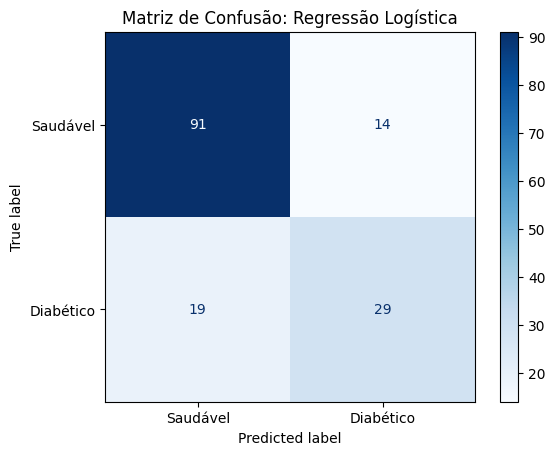

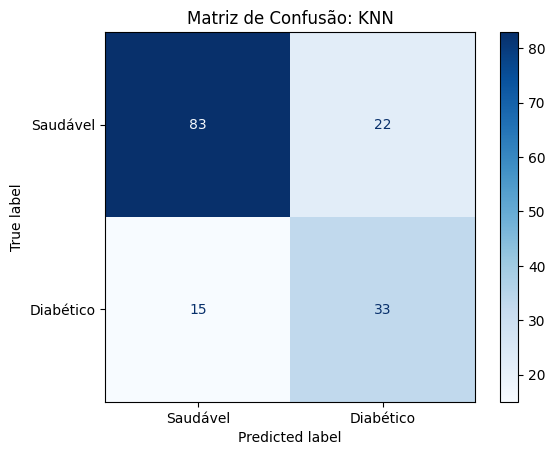

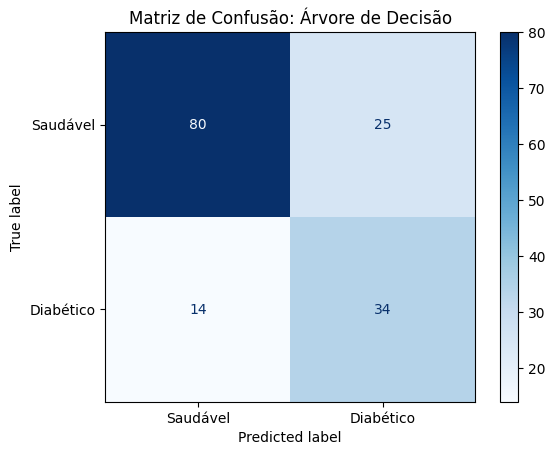

In [81]:
for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Diabético'])
    disp.plot(cmap='Blues', values_format='d')
    
    plt.title(f"Matriz de Confusão: {nome}")
    plt.show()

A análise final dos modelos revela que a acurácia global de 78% da Regressão Logística é enganosa no contexto de saúde, pois o modelo apresenta o pior Recall (60%), deixando de diagnosticar 19 pacientes doentes (Falsos Negativos). Em contraste, a Árvore de Decisão e o KNN, embora tenham acurácias ligeiramente menores (75% e 76%), demonstraram maior sensibilidade clínica. A Árvore de Decisão destacou-se com o melhor Recall (71%), identificando corretamente 34 dos 48 casos de diabetes e minimizando os erros perigosos para apenas 14 pacientes.  Embora o F1-Score tenha empatado em 0.64 para os três modelos, a Árvore de Decisão sagrou-se vencedora por priorizar a detecção da doença em detrimento da precisão pura, provando que a otimização de hiperparâmetros foi eficaz em converter um modelo que antes sofria de overfitting em um detector robusto e seguro para o dataset Pima Indians.

### Etapa 5 — Conclusão

A conclusão deste projeto reforça que o aprendizado de máquina em saúde é um desafio de equilíbrio. O principal insight obtido não foi apenas qual algoritmo "acerta mais", mas como cada um interpreta os dados: a Regressão Logística mostrou-se um modelo conservador e estável, enquanto a Árvore de Decisão e o KNN provaram ser mais flexíveis para capturar padrões complexos após a otimização de hiperparâmetros. O uso do StandardScaler e do Grid Search foi o divisor de águas, transformando modelos que antes sofriam de overfitting (como a Árvore com seus 100% de treino iniciais) em ferramentas com capacidade real de generalização para novos pacientes.

O melhor modelo para este estudo de caso foi a Árvore de Decisão. A justificativa vai além da acurácia: ela apresentou a melhor sensibilidade (Recall de 71%), sendo o algoritmo que menos ignorou pacientes doentes. Em um cenário clínico, "pecar pelo excesso" de cautela (avisar que alguém pode ter diabetes para que ela faça mais exames) é estrategicamente melhor do que dar um falso atestado de saúde a uma pessoa enferma.

Como limitações, destaca-se que o desempenho dos modelos parece ter atingido um "teto" devido à simplicidade dos algoritmos escolhidos e ao tamanho reduzido do dataset Pima Indians. Além disso, a herança genética específica da população estudada limita a generalização dos resultados para outros grupos étnicos. Para trabalhos futuros, a exploração de modelos de Ensemble e a criação de novas variáveis surgem como os caminhos naturais para elevar a precisão do diagnóstico sem sacrificar a segurança clínica.